In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score


#-----------超参数----------------------
rnn_unit = 11           # LSTM 隐藏层神经元数量
lstm_layers = 2         # LSTM 堆叠层数
input_size = 11          # 输入数据特征维度
output_size = 1         # 预测变量维度
lr = 0.0001             # 学习率
batch_size = 104        # 每批次样本量
time_step = 13          # LSTM时间步长
train_begin = 0         # 从数据的第0个索引开始训练
train_end = 1040        # 训练数据结束索引
epochs = 300            # 总训练次数
val_split = 0.2         # 验证数据集占比

#-----------读取数据------------------------
temp2m_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-2m-temperaturenah_itmv.csv')
presure_pcp_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-pressure-precipitationtvg8pjci.csv')
radiation_heat_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-radiation-heat7pwxxuh_.csv')
skin_temp_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-skin-temperature647ijcyf.csv')
snow_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-snowmykwiywx.csv')
soil_temp_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-soil-temperatureccva0hr_.csv')
soil_water_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-soil-watern6c8465e.csv')
wind_data = pd.read_csv('D:/Apy0/ERA5_KAZ/data_cox/reanalysis-era5-land-timeseries-sfc-wind003bzoc7.csv')

ds_data = pd.DataFrame(
    {
        'dewtep2m': temp2m_data['d2m'],
        'pressure': presure_pcp_data['sp'],
        'solar_radiation_heat': radiation_heat_data['ssrd'],
        'thermal_radiation_heat': radiation_heat_data['strd'],
        'skin_temp': skin_temp_data['skt'],
        'snowc': snow_data['snowc'],
        'snow_depth': snow_data['sde'],
        'soil_temp': soil_temp_data['stl1'],
        'soil_water': soil_water_data['swvl1'],
        'v10wind': wind_data['v10'],
        'u10wind': wind_data['u10'],
        'tep2m': temp2m_data['t2m'],
        'totpcp': presure_pcp_data['tp'],
    }
)
ds_data

,dewtep2m,pressure,solar_radiation_heat,thermal_radiation_heat,skin_temp,snowc,snow_depth,soil_temp,soil_water,v10wind,u10wind,tep2m,totpcp
0,265.41577,100117.890,0.0,943428.00,266.39984,96.265625,0.299805,272.31330,0.339767,-0.890354,3.530197,266.63498,0.000075
1,265.02094,100214.310,0.0,937964.60,266.04565,96.265625,0.300781,272.31357,0.339752,-0.957178,3.468124,266.28040,0.000065
2,264.71753,100292.380,0.0,941824.60,265.77533,96.265625,0.300781,272.31433,0.339722,-1.027375,3.335220,266.02330,0.000054
3,264.44473,100363.016,0.0,943161.00,265.54114,96.265625,0.300781,272.31573,0.339691,-1.021331,3.154800,265.79790,0.000039
4,264.19946,100419.310,0.0,940316.25,265.30695,96.265625,0.300781,272.31583,0.339661,-1.040207,2.929398,265.58716,0.000033
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219163,269.44073,98735.390,0.0,1026596.00,270.18005,96.265625,0.237305,273.16534,0.327133,-2.346372,4.080933,270.72595,0.000054
219164,268.52950,98816.430,0.0,1027988.00,269.86255,96.265625,0.237305,273.16797,0.327087,-2.001989,4.360428,270.12595,0.000008
219165,267.82110,98884.280,0.0,968094.00,269.26294,96.265625,0.236328,273.16876,0.327042,-1.182053,4.421783,269.60895,0.000008
219166,267.25745,98949.190,0.0,937646.00,268.73486,96.265625,0.236328,273.16882,0.326996,-0.834609,4.563629,269.34888,0.000012


In [4]:
###-----------数据集重采样----------------------
hourly_series = pd.date_range(start='2000-01-01 00:00:00', end='2024-12-31 23:00:00', freq='h')
ds_data.set_index(hourly_series, inplace=True)
data_week = ds_data.resample('W').mean()   # 按周重采样，取平均值
data_week.index.to_list()
datat0 = data_week.iloc[:, :-1]
datat0.reset_index(drop=True, inplace=True)
data = datat0.iloc[:,:].values
data.shape

(1306, 12)

In [5]:
#-----------数据预处理----------------------
class ERA5Dataset(Dataset):
    """自定义数据集类，将时间序列数据转换为适合LSTM输入的格式"""
    def __init__(self, data, time_step, begin=0, end=None):
        # 截取训练数据集
        data_train = data[begin:end] if end is not None else data[begin:]
        # 计算均值和标准差，并进行标准化
        self.mean = np.mean(data_train, axis=0)
        self.std = np.std(data_train, axis=0)
        self.norm_data = (data_train - self.mean) / self.std

        self.X, self.Y = [], []
        # 构造序列样本数据
        for i in range(len(self.norm_data) - time_step):
            x = self.norm_data[i:i + time_step, :-1]  # 输入特征
            y = self.norm_data[i:i + time_step, -1]    # 目标变量
            self.X.append(x)
            self.Y.append(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), \
               torch.tensor(self.Y[idx], dtype=torch.float32).unsqueeze(-1)  # 增加目标变量的维度以适应LSTM输出

In [6]:
class LSTMModel(nn.Module):
    """LSTM模型定义"""
    def __init__(self, input_size, rnn_size, lstm_layers, output_size):
        super(LSTMModel, self).__init__()
        self.input_fc = nn.Linear(input_size, rnn_size)  # 输入全连接层，将输入特征维度转换为LSTM隐藏层维度 
        self.lstm = nn.LSTM(input_size=rnn_unit, hidden_size=rnn_unit, num_layers=lstm_layers, batch_first=True)
        self.output_fc = nn.Linear(rnn_unit, output_size)

    def forward(self, x):
        x = self.input_fc(x)  # 应用输入全连接层
        out, _ = self.lstm(x)  # LSTM层输出
        out = self.output_fc(out)  # 取最后一个时间步的输出进行全连接层预测
        return out

In [7]:
#--------------数据加载----------------------
dataset = ERA5Dataset(data, time_step, train_begin, train_end)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size]) # 划分训练集和验证集
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # 训练数据加载器，启用随机打乱
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # 验证数据加载,不打乱

In [8]:
#-----------调用模型、优化器、损失函数----------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size, rnn_unit, lstm_layers, output_size).to(device)
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam优化器

In [9]:
#-----------训练----------------------
best_val_loss = float('inf')   # 保存最优验证损失
best_model_state = None       # 保存最优模型参数

for epoch in range(epochs):   
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)  # 去掉目标变量的最后一个维度
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    avg_train_loss = epoch_loss / len(train_loader.dataset)

    # ---------------验证阶段-----------------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():   # 在验证阶段不计算梯度，节省内存和计算资源
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')  # 保存最优模型参数

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}')

print(f'Best Validation Loss: {best_val_loss:.6f}')
print("Training complete. Best model saved at:", 'best_model.pth')

Epoch [1/300], Train Loss: 1.051428, Val Loss: 1.054008
Epoch [2/300], Train Loss: 1.046654, Val Loss: 1.049803
Epoch [3/300], Train Loss: 1.041807, Val Loss: 1.045545
Epoch [4/300], Train Loss: 1.036966, Val Loss: 1.041219
Epoch [5/300], Train Loss: 1.031947, Val Loss: 1.036820
Epoch [6/300], Train Loss: 1.026973, Val Loss: 1.032319
Epoch [7/300], Train Loss: 1.021904, Val Loss: 1.027709
Epoch [8/300], Train Loss: 1.016552, Val Loss: 1.023000
Epoch [9/300], Train Loss: 1.011344, Val Loss: 1.018068
Epoch [10/300], Train Loss: 1.005867, Val Loss: 1.012957
Epoch [11/300], Train Loss: 1.000018, Val Loss: 1.007731
Epoch [12/300], Train Loss: 0.994250, Val Loss: 1.002202
Epoch [13/300], Train Loss: 0.988183, Val Loss: 0.996423
Epoch [14/300], Train Loss: 0.981778, Val Loss: 0.990389
Epoch [15/300], Train Loss: 0.975112, Val Loss: 0.984083
Epoch [16/300], Train Loss: 0.968297, Val Loss: 0.977372
Epoch [17/300], Train Loss: 0.960968, Val Loss: 0.970385
Epoch [18/300], Train Loss: 0.953340, Va

In [14]:
#-----------模型测试----------------------
def prediction(time_step=20):
    #对测试集进行预测并绘图
    data_test = data[train_end:]  # 测试数据集
    mean = np.mean(data_test, axis=0)
    std = np.std(data_test, axis=0)
    norm_test_data = (data_test - mean) / std  # 标准化测试数据

    size = (len(norm_test_data) + time_step - 1 ) // time_step 
    test_x, test_y = [], []
    for i in range(size - 1):
        x = norm_test_data[i*time_step:(i+1)*time_step, :-1]  # 输入特征
        y = norm_test_data[i*time_step:(i+1)*time_step, -1]    # 目标变量
        test_x.append(x)
        test_y.extend(y)
    x_last = norm_test_data[(i+1)*time_step:, :-1]  # 最后一个时间步的输入特征
    y_last = norm_test_data[(i+1)*time_step:, -1]    # 最后一个时间步的目标变量
    if len(x_last) > 0:
        test_x.append(x_last)
        test_y.extend(y_last)
    
    ###----------------加载最优模型参数----------------------
    model.load_state_dict(torch.load('best_model.pth'))   # 加载训练得到的权重
    model.eval()

    ###----------------预测----------------------
    test_predict = []
    with torch.no_grad():
        for seq in test_x:
            seq_tensor = torch.tensor(seq[np.newaxis, :], dtype=torch.float32).to(device)  # 添加批次维度并转换为张量
            pred = model(seq_tensor).cpu().numpy().reshape(-1)  
            test_predict.extend(pred) 

    ###----------------反标准化----------------------
    test_y = np.array(test_y) * std[-1] + mean[-1]
    test_y = test_y - 273.15
    test_predict = np.array(test_predict)*std[-1] + mean[-1]  # 反标准化预测结果
    test_predict = test_predict - 273.15

    ###----------------评估指标----------------------
    mean_rel_error = np.mean(np.abs(test_predict - test_y[:len(test_predict)]) / test_y[:len(test_predict)])*100  # 平均相对误差
    r2 = r2_score(test_y[:len(test_predict)], test_predict)  

    print(f'Mean Relative Error: {mean_rel_error:.3f}%, R² Score: {r2:.4f}')

    ###----------------绘图----------------------
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(len(test_predict))), test_predict, label='LSTM-pred')
    plt.plot(list(range(len(test_y))), test_y, label='ERA5-Real')
    plt.ylabel("T2M(°C)")
    plt.legend(loc='upper left')
    plt.show()


Mean Relative Error: 22.859%, R² Score: 0.9686


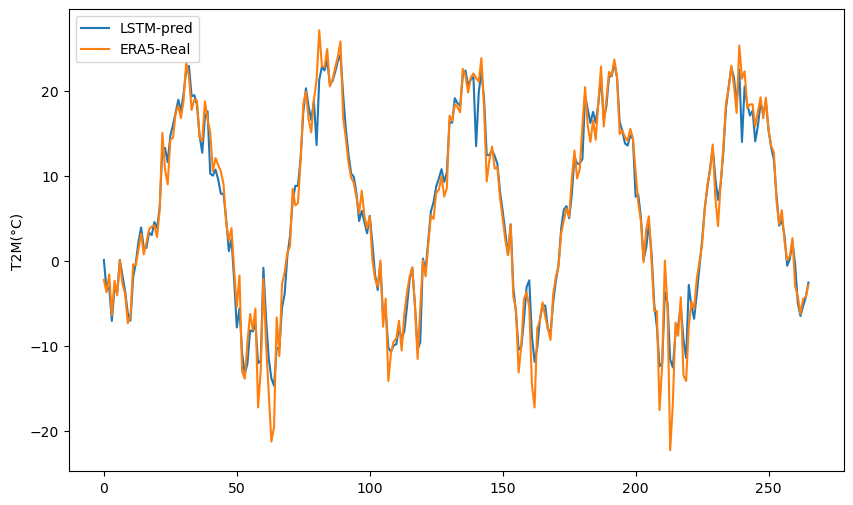

In [15]:
prediction()